# Rational-`r` + per-corner `k` optimisation for HE-notatable tilings

Pipeline strategy:

1. Run `penrose5D.ipynb` as-is &rarr; `Data/indices_5Dprojection.txt`.
2. This notebook expresses the global multiplier `r` directly in **absorbed form** — integer exponent shifts `(α, β, γ, ε)` baked into the 5D exponents — and adds a per-corner `(1,1,1,1,1)·k_i` translation to bring each corner into Helmholtz–Ellis notation limits (`|5|≤4, |7|≤2, |11|≤1`).
3. Writes `Data/indices_5Doptimized.txt` &mdash; the same row/column shape as `indices_5Dprojection.txt` (one row per tile, 20 integers = 4 corners × 5 exponents), with `(α, β, γ, ε)` baked into every corner and per-corner `k_i` applied.
4. With the optimised file in hand, SC's `~freqRatioScalar` can be set to `1.0` &mdash; all of `r` is now in the exponents, so notation (read off the file) and playback (computed from the file) agree exactly.

## Why search integer exponent shifts `(α, β, γ, ε)`?

In `combined_optimization.ipynb` the multiplier `r` was treated as a continuous real, but its optimum is in fact an **exact 11-limit rational**: every analytic candidate there has the form `(target / node-ratio) · 2^m`, and the best value is `r = 1408/1225 = 2⁷·11/(5²·7²)` — see the rationality cell in that notebook. That is already of the form

$$r = 3^{α}\,5^{β}\,7^{γ}\,11^{ε}\,2^{ν}$$

with `(α, β, γ, ε) = (0, −2, −2, +1)` and `ν = 7`. So rationality needs no enforcement; searching the integer box `[−K, K]⁴` directly serves two purposes:

1. it produces `r` in absorbed form, so `(α, β, γ, ε)` can be baked into every corner's 5D exponents and HE notation (read off the file) agrees exactly with playback — the point of this notebook;
2. the optimum is degenerate — the box contains a family of `(α, β, γ, ε)` tied at the same match count, related by `(1,1,1,1,1)` trace translations (verified in the degeneracy cell below); the per-corner `k_i` absorbs the difference, so the final result is invariant to which member is chosen.

The `2^{ν}` factor cannot be baked into the 5-vector (no 2-axis in the file) and would only shift octaves — SC's `~limitRange` / `~singleOctave` re-locates pitch into an audible band at playback, so dropping `ν` is harmless.

## How matching works under rational `r`

`{log 2, log 3, log 5, log 7, log 11}` are `Q`-linearly independent. An *octave-equivalent* match of two ratios built from these primes is therefore an exact integer identity on the non-2 exponents (plus an arbitrary integer multiple of `log 2`, which is octave-irrelevant and is discarded). For a corner with effective exponents `(A_i, B_i, C_i, E_i)` &mdash; where `A_i = a_i + 2·d_i` (9-axis folded into 3) &mdash; and a Diamond/Eikosany target with `(A*, B*, C*, E*)`, the match condition under `(α, β, γ, ε)` and per-corner `k_i` is the four integer equations

```
A_i + α + 3·k_i = A*
B_i + β +   k_i = B*
C_i + γ +   k_i = C*
E_i + ε +   k_i = E*
```

The last three force a single `k_i = B*−B_i−β = C*−C_i−γ = E*−E_i−ε`; the first then demands `(A*−A_i−α)` be divisible by 3 (because the `(1,1,1,1,1)·k_i` shift moves the 3-axis effective by `3·k_i`). HE-rep limits are automatic for matched corners because every Diamond/Eikosany canonical exponent already fits within HE.

## Output 5-vectors are NOT octave-folded

The written 5-vectors contain raw integer exponents of `{3, 5, 7, 9, 11}`. A corner's ratio under those exponents can be larger than 2 or smaller than 1; nothing in this notebook coerces it into `[1, 2)`. The `% log2` operations used here are matching tests (testing octave equivalence with the target set), **not** transformations of the vectors themselves. SC's `~limitRange` brings the absolute pitch into an audible band at runtime.

In [1]:
import sys
sys.path.insert(0, '../src')
import numpy as np
import json
from fractions import Fraction
from itertools import product as iproduct

from ji_tiling import DIAMOND_RATIOS, HE_LIMITS

# Load extended Eikosany set
with open('../Data/eikosany_diamond.json', 'r') as f:
    eikos_ALL = json.load(f)

# Load tile-corner indices: each row = 4 corners × 5 exponents
raw = np.loadtxt('../Data/indices_5Dprojection.txt', delimiter=',', dtype=int)
print(f'Tiles in indices_5Dprojection.txt: {raw.shape[0]}')

nodes_all = raw.reshape(-1, 4, 5).reshape(-1, 5)
unique_nodes, inverse_idx = np.unique(nodes_all, axis=0, return_inverse=True)
print(f'Unique 5D nodes : {len(unique_nodes)}')

Tiles in indices_5Dprojection.txt: 227
Unique 5D nodes : 258


In [2]:
# Effective (3, 5, 7, 11) exponents of a ratio. 9-factors fold into 3 (9 = 3^2).
# 2-factors are absorbed into octave-equivalence and dropped — see header.
def ratio_to_effective(num, den):
    n, d = int(num), int(den)
    a3 = b5 = c7 = e11 = 0
    for prime, slot in [(2, None), (3, 'a3'), (5, 'b5'), (7, 'c7'), (11, 'e11')]:
        while n % prime == 0:
            n //= prime
            if slot == 'a3': a3 += 1
            elif slot == 'b5': b5 += 1
            elif slot == 'c7': c7 += 1
            elif slot == 'e11': e11 += 1
        while d % prime == 0:
            d //= prime
            if slot == 'a3': a3 -= 1
            elif slot == 'b5': b5 -= 1
            elif slot == 'c7': c7 -= 1
            elif slot == 'e11': e11 -= 1
    if n != 1 or d != 1:
        raise ValueError(f'{num}/{den}: residual {n}/{d} not in {{2,3,5,7,11}}')
    return (a3, b5, c7, e11)


diamond_targets = sorted({ratio_to_effective(n, d) for (n, d) in DIAMOND_RATIOS})
eiko_targets    = sorted({ratio_to_effective(n, d) for (n, d) in zip(eikos_ALL['num'], eikos_ALL['den'])}
                          - set(diamond_targets))

target_exps = np.array(diamond_targets + eiko_targets, dtype=int)
target_kind = np.array(['Diamond'] * len(diamond_targets) + ['Eikosany'] * len(eiko_targets))
print(f'Diamond targets (unique effective)        : {len(diamond_targets)}')
print(f'Eikosany targets (effective, ex-Diamond)  : {len(eiko_targets)}')
print(f'Total target effective vectors            : {len(target_exps)}')

Diamond targets (unique effective)        : 29
Eikosany targets (effective, ex-Diamond)  : 86
Total target effective vectors            : 115


In [3]:
# Effective (A, B, C, E) per unique node. A = a + 2·d (9-axis folded into 3).
unique_eff = np.column_stack([
    unique_nodes[:, 0] + 2 * unique_nodes[:, 3],
    unique_nodes[:, 1],
    unique_nodes[:, 2],
    unique_nodes[:, 4],
])
print(f'unique_eff shape: {unique_eff.shape}')

unique_eff shape: (258, 4)


In [4]:
# Brute-force search over (α, β, γ, ε) ∈ [-K, K]^4 and per-corner k_i.
# For each (α, β, γ, ε), for each corner i, scan target_exps for a target whose
# match equations yield a consistent integer k_i AND satisfy the 3-axis
# divisibility (A* − A_i − α) ≡ 0 (mod 3).  HE-rep limits are automatic for matched
# corners because every Diamond/Eikosany canonical exponent fits within HE.

K = 4
n_c = len(unique_eff)
n_t = len(target_exps)

A_i = unique_eff[:, 0][:, None]
B_i = unique_eff[:, 1][:, None]
C_i = unique_eff[:, 2][:, None]
E_i = unique_eff[:, 3][:, None]
A_j = target_exps[:, 0][None, :]
B_j = target_exps[:, 1][None, :]
C_j = target_exps[:, 2][None, :]
E_j = target_exps[:, 3][None, :]

best_count, best_params = -1, None
best_k_arr, best_j_arr  = None, None

for alpha, beta, gamma, eps in iproduct(range(-K, K + 1), repeat=4):
    k_b = B_j - B_i - beta
    k_c = C_j - C_i - gamma
    k_e = E_j - E_i - eps
    consistent = (k_b == k_c) & (k_b == k_e)
    A_ok       = (A_j - A_i - alpha - 3 * k_b) == 0
    matched    = consistent & A_ok
    any_match  = matched.any(axis=1)
    count = int(any_match.sum())
    if count > best_count:
        best_count  = count
        best_params = (alpha, beta, gamma, eps)
        first_j = np.where(matched, np.arange(n_t)[None, :], n_t).min(axis=1)
        best_j_arr = np.where(any_match, first_j, -1)
        gather_j   = first_j.clip(max=n_t - 1)
        best_k_arr = np.where(any_match, k_b[np.arange(n_c), gather_j], 0)

alpha, beta, gamma, eps = best_params
n_d = int(((best_j_arr >= 0) & (target_kind[best_j_arr.clip(min=0)] == 'Diamond')).sum())
n_e = int(((best_j_arr >= 0) & (target_kind[best_j_arr.clip(min=0)] == 'Eikosany')).sum())

print(f'Search range (K)   : ±{K}')
print(f'Best (α, β, γ, ε)  : {best_params}')
print(f'Matched corners    : {best_count} / {n_c}')
print(f'  Diamond           : {n_d}')
print(f'  Eikosany          : {n_e}')

# Display r as a rational and as an octave-normalised float
num_factors, den_factors = [], []
for p, ex in [(3, alpha), (5, beta), (7, gamma), (11, eps)]:
    if   ex > 0: num_factors.append(f'{p}^{ex}' if ex > 1 else f'{p}')
    elif ex < 0: den_factors.append(f'{p}^{-ex}' if -ex > 1 else f'{p}')
num_str = ' · '.join(num_factors) if num_factors else '1'
den_str = ' · '.join(den_factors) if den_factors else '1'
r_val   = Fraction((3**alpha if alpha >= 0 else 1) * (5**beta if beta >= 0 else 1)
                   * (7**gamma if gamma >= 0 else 1) * (11**eps if eps >= 0 else 1),
                   (3**-alpha if alpha < 0 else 1) * (5**-beta if beta < 0 else 1)
                   * (7**-gamma if gamma < 0 else 1) * (11**-eps if eps < 0 else 1))
r_oct = r_val
while r_oct >= 2: r_oct /= 2
while r_oct < 1:  r_oct *= 2
print(f'r                  = ({num_str}) / ({den_str})  = {r_val}')
print(f'r (octave-folded)  ≈ {float(r_oct):.8f}  =  {r_oct}')

Search range (K)   : ±4
Best (α, β, γ, ε)  : (-3, -3, -3, 0)
Matched corners    : 62 / 258
  Diamond           : 22
  Eikosany          : 40
r                  = (1) / (3^3 · 5^3 · 7^3)  = 1/1157625
r (octave-folded)  ≈ 1.81159875  =  2097152/1157625


In [5]:
# For matched corners, k_i is fixed by the matching equations.
# For unmatched corners, pick the smallest |k_i| satisfying HE limits under
# the chosen (α, β, γ, ε).  If no such k_i exists, leave it at 0 and flag
# the corner as HE-violating (its exponents will sit outside heji-ly's range).

alpha, beta, gamma, eps = best_params
b_arr = unique_nodes[:, 1]
c_arr = unique_nodes[:, 2]
e_arr = unique_nodes[:, 4]

k_lo = np.maximum.reduce([-b_arr - beta - HE_LIMITS[5],
                          -c_arr - gamma - HE_LIMITS[7],
                          -e_arr - eps - HE_LIMITS[11]])
k_hi = np.minimum.reduce([-b_arr - beta + HE_LIMITS[5],
                          -c_arr - gamma + HE_LIMITS[7],
                          -e_arr - eps + HE_LIMITS[11]])
he_feasible_unmatched = k_lo <= k_hi

unmatched_k = np.zeros(n_c, dtype=int)
m_pos = he_feasible_unmatched & (k_lo > 0)
m_neg = he_feasible_unmatched & (k_hi < 0)
unmatched_k[m_pos] = k_lo[m_pos]
unmatched_k[m_neg] = k_hi[m_neg]

is_matched = (best_j_arr >= 0)
final_k    = np.where(is_matched, best_k_arr, unmatched_k)

final_b = b_arr + beta + final_k
final_c = c_arr + gamma + final_k
final_e = e_arr + eps + final_k
he_ok = ((np.abs(final_b) <= HE_LIMITS[5]) & (np.abs(final_c) <= HE_LIMITS[7])
         & (np.abs(final_e) <= HE_LIMITS[11]))

print(f'Per-corner k assignment:')
print(f'  matched D∪E (k_i fixed by match)         : {int(is_matched.sum())}')
print(f'  unmatched + HE-feasible (k_i for HE)     : {int((~is_matched &  he_feasible_unmatched).sum())}')
print(f'  unmatched + HE-infeasible (k_i = 0)      : {int((~is_matched & ~he_feasible_unmatched).sum())}')
print(f'  final HE-ok corners                      : {int(he_ok.sum())} / {n_c}')

Per-corner k assignment:
  matched D∪E (k_i fixed by match)         : 62
  unmatched + HE-feasible (k_i for HE)     : 62
  unmatched + HE-infeasible (k_i = 0)      : 134
  final HE-ok corners                      : 124 / 258


In [ ]:
# Degeneracy check: enumerate ALL (α, β, γ, ε) in the box tied at best_count and
# confirm the combined_optimization optimum r = 1408/1225 <-> (0, -2, -2, +1) is
# among them.  The ties form a single trace-translation family — consecutive
# members differ by (Δα, Δβ, Δγ, Δε) = (3, 1, 1, 1), one (1,1,1,1,1) step in
# effective exponents — which the per-corner k_i absorbs, so match counts,
# final HE-ok counts, and final pitches are identical for every member.

def match_info(params):
    alpha_, beta_, gamma_, eps_ = params
    k_b = B_j - B_i - beta_
    m = ((k_b == C_j - C_i - gamma_) & (k_b == E_j - E_i - eps_)
         & ((A_j - A_i - alpha_ - 3 * k_b) == 0))
    any_m   = m.any(axis=1)
    first_j = np.where(m, np.arange(n_t)[None, :], n_t).min(axis=1)
    j_arr   = np.where(any_m, first_j, -1)
    k_arr   = np.where(any_m, k_b[np.arange(n_c), first_j.clip(max=n_t - 1)], 0)
    return int(any_m.sum()), j_arr, k_arr

def final_he_ok_count(params, j_arr, k_arr):
    """Cell-5 per-corner-k + HE check for arbitrary params."""
    alpha_, beta_, gamma_, eps_ = params
    lo = np.maximum.reduce([-b_arr - beta_ - HE_LIMITS[5],
                            -c_arr - gamma_ - HE_LIMITS[7],
                            -e_arr - eps_ - HE_LIMITS[11]])
    hi = np.minimum.reduce([-b_arr - beta_ + HE_LIMITS[5],
                            -c_arr - gamma_ + HE_LIMITS[7],
                            -e_arr - eps_ + HE_LIMITS[11]])
    feas = lo <= hi
    uk = np.zeros(n_c, dtype=int)
    uk[feas & (lo > 0)] = lo[feas & (lo > 0)]
    uk[feas & (hi < 0)] = hi[feas & (hi < 0)]
    fk = np.where(j_arr >= 0, k_arr, uk)
    return int(((np.abs(b_arr + beta_ + fk) <= HE_LIMITS[5])
                & (np.abs(c_arr + gamma_ + fk) <= HE_LIMITS[7])
                & (np.abs(e_arr + eps_ + fk) <= HE_LIMITS[11])).sum())

def r_octave_folded(params):
    alpha_, beta_, gamma_, eps_ = params
    r = Fraction(3)**alpha_ * Fraction(5)**beta_ * Fraction(7)**gamma_ * Fraction(11)**eps_
    while r >= 2: r /= 2
    while r < 1:  r *= 2
    return r

ties = []
for params in iproduct(range(-K, K + 1), repeat=4):
    cnt, j_arr, k_arr = match_info(params)
    if cnt == best_count:
        ties.append((params, j_arr, k_arr))

print(f'(α, β, γ, ε) tied at {best_count} matches in [-{K}, {K}]^4: {len(ties)}')
for params, j_arr, k_arr in ties:
    r_o = r_octave_folded(params)
    he  = final_he_ok_count(params, j_arr, k_arr)
    tag = '   <-- combined_optimization optimum 1408/1225' if params == (0, -2, -2, 1) else ''
    print(f'  {str(params):18s}  r (octave-folded) = {str(r_o):>17s} = {float(r_o):.8f}'
          f'   final HE-ok = {he}{tag}')

assert any(p == (0, -2, -2, 1) for p, _, _ in ties), \
    'combined_optimization optimum missing from tie set'
sorted_ties = sorted(p for p, _, _ in ties)
for t1, t2 in zip(sorted_ties, sorted_ties[1:]):
    assert tuple(np.subtract(t2, t1)) == (3, 1, 1, 1), (t1, t2)
print()
print('Tie family confirmed: consecutive members differ by (3,1,1,1) — one (1,1,1,1,1)')
print('trace step in effective exponents, absorbed by the per-corner k_i.')

In [6]:
# Reconstruct the 2D Penrose projection p (E∥) and check how the optimised
# coords project relative to the originals.
#
# Theory: A4 ⊥ (1,1,1,1,1), so p · (1,1,1,1,1) = 0 — the per-corner k_i term
# (1,1,1,1,1)·k_i is in the kernel of p and leaves 2D positions untouched.
# The GLOBAL (α, β, γ, 0, ε) shift is a different 5D vector — it is NOT a
# multiple of (1,1,1,1,1) in general, so p · (α, β, γ, 0, ε) ≠ 0 and the
# optimised tiling is uniformly TRANSLATED in 2D relative to the original.

from ji_tiling import setup_a4_projection
_, p_2d, _ = setup_a4_projection()
sv_fixed = np.array([4/5, -1/5, -1/5, -1/5, -1/5])

alpha, beta, gamma, eps = best_params
ones5 = np.ones(5)

# 2D positions: original vs. fully-optimised (global shift + per-corner k)
xy_orig         = (unique_nodes + sv_fixed) @ p_2d.T
optimised_nodes = (unique_nodes
                   + np.array([alpha, beta, gamma, 0, eps])
                   + final_k[:, None] * ones5[None, :])
xy_opt          = (optimised_nodes + sv_fixed) @ p_2d.T
delta_xy        = xy_opt - xy_orig

# Per-corner k_i ALONE (no global shift) — must project to identical 2D positions.
k_only_nodes = unique_nodes + final_k[:, None] * ones5[None, :]
xy_k_only    = (k_only_nodes + sv_fixed) @ p_2d.T
delta_k_only = xy_k_only - xy_orig

# Just the global (α, β, γ, 0, ε) shift in 2D
expected_global_shift = p_2d @ np.array([alpha, beta, gamma, 0, eps], dtype=float)

print(f'p · (1,1,1,1,1)                = {p_2d @ ones5}      (expected ≈ 0)')
print(f'max |Δxy from k_i alone|       = {np.abs(delta_k_only).max():.3e}      (expected 0)')
print()
print(f'p · (α, β, γ, 0, ε)            = {expected_global_shift}')
print(f'max |Δxy − expected_shift|     = {np.abs(delta_xy - expected_global_shift).max():.3e}')
print(f'Δxy norm range across corners  = '
      f'[{np.linalg.norm(delta_xy, axis=1).min():.6f}, {np.linalg.norm(delta_xy, axis=1).max():.6f}]')
print()
if np.allclose(expected_global_shift, 0):
    print('expected_global_shift ≈ 0 → optimised and original tilings overlay exactly.')
else:
    print('expected_global_shift ≠ 0 → the optimised tiling is uniformly TRANSLATED')
    print('  relative to the original by p · (α, β, γ, 0, ε).')
    print('  The per-corner k_i is invisible to p (it lives in p\'s kernel), but the global')
    print('  rational-r exponents do move 2D positions by a CONSTANT vector — same for every')
    print('  corner.  Implication: the existing verts file (computed from the original coords)')
    print('  and the new indices file describe tilings offset by this constant.  Options:')
    print('   (a) translate the verts file by the same constant when using the optimised file;')
    print('   (b) compensate inside SC drawing code;')
    print('   (c) compute ji_membership xy positions from the ORIGINAL coords (which match')
    print('       the verts file) and accept the bookkeeping offset between drawn tiles and')
    print('       per-corner frequencies.  This is the simplest path and what the next cell does.')

2D projection plane (E∥):
-->5D basis vectors are rotated in 2D plane by (2.0π)/5
3D acceptance-window space (E⊥ + uniform):
-->5D basis vectors are rotated in 2D plane by (3.9999999999999996π)/5
p · (1,1,1,1,1)                = [-1.11022302e-16 -4.44089210e-16]      (expected ≈ 0)
max |Δxy from k_i alone|       = 8.882e-16      (expected 0)

p · (α, β, γ, 0, ε)            = [-0.9486833   2.91974697]
max |Δxy − expected_shift|     = 8.882e-16
Δxy norm range across corners  = [3.070004, 3.070004]

expected_global_shift ≠ 0 → the optimised tiling is uniformly TRANSLATED
  relative to the original by p · (α, β, γ, 0, ε).
  The per-corner k_i is invisible to p (it lives in p's kernel), but the global
  rational-r exponents do move 2D positions by a CONSTANT vector — same for every
  corner.  Implication: the existing verts file (computed from the original coords)
  and the new indices file describe tilings offset by this constant.  Options:
   (a) translate the verts file by the same const

In [7]:
# Apply (α, β, γ, ε) + per-corner k_i to every tile-corner slot in raw.
# Each slot's k_i comes from its unique-node index via `inverse_idx`.
# r has no 2-axis component, so the 9-axis (column 3) receives only the
# per-corner k_i; the (1,1,1,1,1) translation alone moves the 9-exp by k_i.

alpha, beta, gamma, eps = best_params
slot_k = final_k[inverse_idx]

shifts = np.column_stack([
    alpha + slot_k,    # 3-axis: α (from r) + k
    beta  + slot_k,    # 5-axis
    gamma + slot_k,    # 7-axis
    0     + slot_k,    # 9-axis: only k (r contributes nothing here)
    eps   + slot_k,    # 11-axis
])

shifted_nodes = nodes_all + shifts
shifted_rows  = shifted_nodes.reshape(-1, 20)

OUTPUT_FILE = '../Data/indices_5Doptimized.txt'
np.savetxt(OUTPUT_FILE, shifted_rows, fmt='%d', delimiter=',')
print(f'Wrote {OUTPUT_FILE}')
print(f'  tiles      : {shifted_rows.shape[0]}')
print(f'  exponent ranges per axis:')
for axis, name in enumerate(['3', '5', '7', '9', '11']):
    col = shifted_nodes[:, axis]
    print(f'    {name:>2}: min={col.min():+d}  max={col.max():+d}  abs-max={int(np.abs(col).max())}')

Wrote ../Data/indices_5Doptimized.txt
  tiles      : 227
  exponent ranges per axis:
     3: min=-6  max=+1  abs-max=6
     5: min=-6  max=+2  abs-max=6
     7: min=-6  max=+2  abs-max=6
     9: min=-3  max=+3  abs-max=3
    11: min=-1  max=+3  abs-max=3


Wrote ../Data/ji_membership_optimized.json
  freqRatioScalar = 1.0   (r absorbed into indices_5Doptimized.txt)
  Diamond markers  : 22
  Eikosany markers : 40


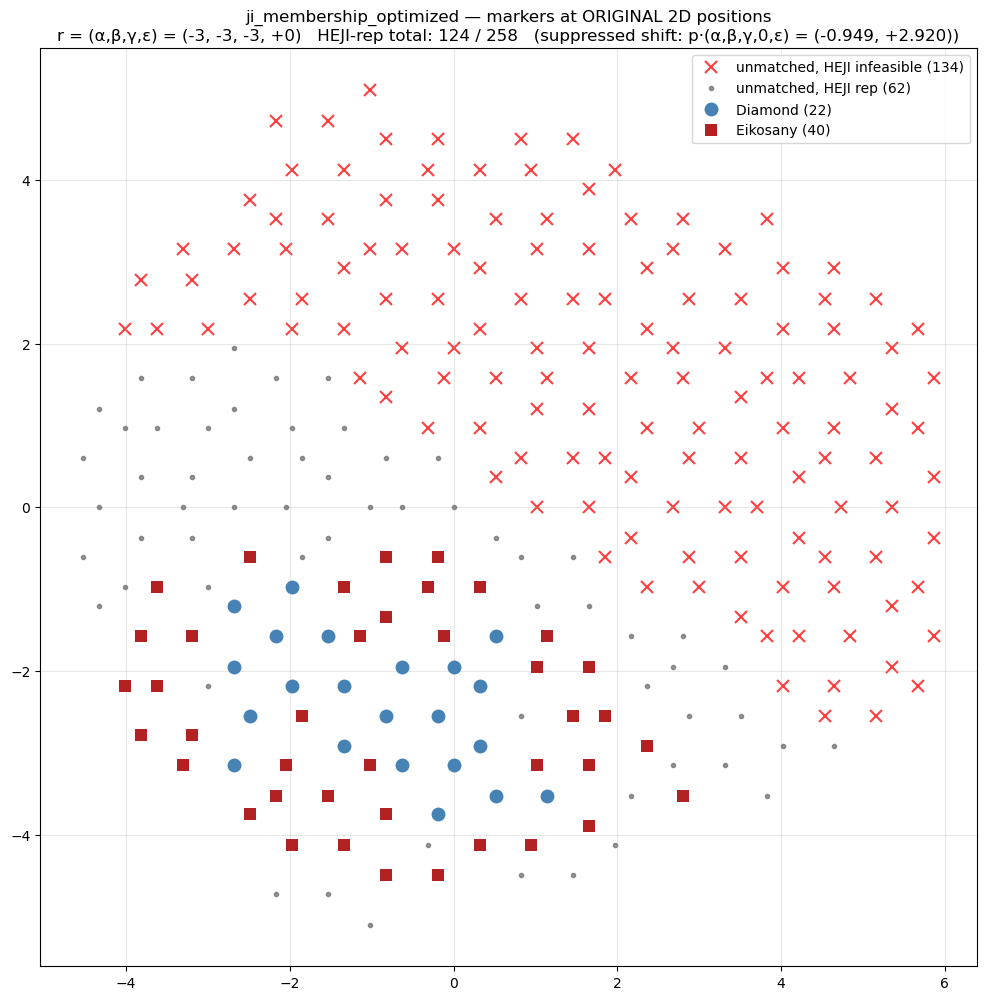

In [8]:
# Write Data/ji_membership_optimized.json — the partner file for indices_5Doptimized.txt.
#
# IMPORTANT: xy positions here are computed from the ORIGINAL coordinates
#   (unique_nodes + sv_fixed) projected by p — NOT from the optimised coordinates.
# The optimised coords would project to xy_orig + p·(α, β, γ, 0, ε), which is a
# uniform 2D translation ≠ 0 (≈ (-0.95, +2.92) for this dataset, surfaced in the
# verification cell).  We deliberately discard that constant translation so the
# membership markers align with the existing verts_5Dprojection.txt tile corners
# — the file SC actually draws from.  The geometric "natural" position of an
# optimised corner is never used by the SC pipeline; it exists only in the abstract
# projection of the optimised exponents.
#
# Consequence: the marker dots sit at the original tile-corner positions and
# the playback frequency at each marker corresponds to a Diamond/Eikosany ratio
# (after the rational-r and per-corner-k shifts baked into indices_5Doptimized.txt).
# Notation and playback agree exactly; the geometric/algebraic offset between
# "where the original lattice point sits" and "where the optimised exponents
# would sit" is harmlessly suppressed.

import json
import matplotlib.pyplot as plt

diamond_idx  = [i for i in range(n_c)
                if best_j_arr[i] >= 0 and target_kind[best_j_arr[i]] == 'Diamond']
eikosany_idx = [i for i in range(n_c)
                if best_j_arr[i] >= 0 and target_kind[best_j_arr[i]] == 'Eikosany']

diamond_xy  = xy_orig[diamond_idx].tolist()
eikosany_xy = xy_orig[eikosany_idx].tolist()

ji_data_optimized = {
    'freqRatioScalar': 1.0,    # r is now baked into indices_5Doptimized.txt
    'diamondCount':    len(diamond_xy),
    'diamondNodes':    diamond_xy,
    'eikosanyCount':   len(eikosany_xy),
    'eikosanyNodes':   eikosany_xy,
}

out_path = '../Data/ji_membership_optimized.json'
with open(out_path, 'w') as f:
    json.dump(ji_data_optimized, f, indent=2)

print(f'Wrote {out_path}')
print(f'  freqRatioScalar = 1.0   (r absorbed into indices_5Doptimized.txt)')
print(f'  Diamond markers  : {len(diamond_xy)}')
print(f'  Eikosany markers : {len(eikosany_xy)}')

# Plot — original 2D layout, with four categories per corner:
#   1. Diamond match              (steelblue circle)
#   2. Eikosany match             (firebrick square)
#   3. Unmatched but HE-rep       (small grey dot)        — playable & notatable, just not in D ∪ E
#   4. Unmatched and HE-infeasible (red ×)                — playable, but cannot be notated in HEJI
# Categories 3 and 4 use `he_ok` (computed in unmatched-cell) which holds the HE-rep status
# of each corner's FINAL exponents after the (α, β, γ, ε) + k_i shift.  Matched corners are
# automatically HE-rep (their final exponents are exactly a Diamond/Eikosany canonical form).
is_d_match     = np.array([best_j_arr[i] >= 0 and target_kind[best_j_arr[i]] == 'Diamond'  for i in range(n_c)])
is_e_match     = np.array([best_j_arr[i] >= 0 and target_kind[best_j_arr[i]] == 'Eikosany' for i in range(n_c)])
is_unmatch_he  = (~is_matched) &  he_ok
is_unmatch_no  = (~is_matched) & ~he_ok

n_d_pl = int(is_d_match.sum())
n_e_pl = int(is_e_match.sum())
n_u_he = int(is_unmatch_he.sum())
n_u_no = int(is_unmatch_no.sum())

fig, ax = plt.subplots(figsize=(10, 10))

# Layer order: HE-infeasible first (background), then HE-rep dots, then matched markers on top.
if n_u_no:
    ax.plot(xy_orig[is_unmatch_no, 0], xy_orig[is_unmatch_no, 1],
            'x', color='red', markersize=8, markeredgewidth=1.5, alpha=0.75,
            label=f'unmatched, HEJI infeasible ({n_u_no})', zorder=1)
if n_u_he:
    ax.plot(xy_orig[is_unmatch_he, 0], xy_orig[is_unmatch_he, 1],
            '.', color='dimgrey', markersize=6, alpha=0.7,
            label=f'unmatched, HEJI rep ({n_u_he})', zorder=2)
if n_d_pl:
    ax.plot(xy_orig[is_d_match, 0], xy_orig[is_d_match, 1],
            'o', color='steelblue', markersize=10, markeredgewidth=0,
            label=f'Diamond ({n_d_pl})', zorder=3)
if n_e_pl:
    ax.plot(xy_orig[is_e_match, 0], xy_orig[is_e_match, 1],
            's', color='firebrick', markersize=8, markeredgewidth=0,
            label=f'Eikosany ({n_e_pl})', zorder=3)

shift_str = f'p·(α,β,γ,0,ε) = ({expected_global_shift[0]:+.3f}, {expected_global_shift[1]:+.3f})'
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10, loc='upper right')
ax.set_title('ji_membership_optimized — markers at ORIGINAL 2D positions\n'
             f'r = (α,β,γ,ε) = ({alpha:+d}, {beta:+d}, {gamma:+d}, {eps:+d})   '
             f'HEJI-rep total: {n_d_pl + n_e_pl + n_u_he} / {n_c}   '
             f'(suppressed shift: {shift_str})')
plt.tight_layout()
plt.show()

## Notes on the 2-factor and SC playback

* The output file's 5-vectors are **not** octave-folded. Each is the raw integer exponent of `{3, 5, 7, 9, 11}` after the rational-`r` shift and per-corner `k`. The actual JI ratio of a corner can sit far above 2 or below 1; SC's `~limitRange` (or `~singleOctave`) brings the pitch into an audible band at playback.
* The rational `r` may carry a `2^{ν}` factor, but it cannot be baked into the 5-vector (no 2-axis in the file). Dropping it is harmless because it's a pure octave shift that `~limitRange` would undo anyway.
* With the optimised file in hand, `tiling_simple.scd` should run with `~freqRatioScalar = 1.0` &mdash; all of `r` has been absorbed into the exponents, so the runtime scalar is the identity. Notation (read off the file) and playback (computed from the file) agree exactly.
* The 9-axis (column 3) receives only the `(1,1,1,1,1)·k_i` shift, because `r` has no 9-component (9 is not prime). The 3-axis carries the `α` from `r` plus the same `k_i`.